# Prescriptive Analysis

## 1. Should insulin bolus dosage be adjusted when glucose spikes occur after periods of inactivity?
### Markers Chosen
* glucose
* steps
* bolus_volume_delivered
### Why These Markers?
Low physical activity (steps) often contributes to higher glucose levels.
Bolus insulin is used to reduce post-meal glucose spikes.
Understanding the relationship helps recommend personalized insulin corrections.
### Medical Influence
Sedentary behavior can reduce insulin sensitivity, causing glucose to remain elevated longer.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv( 'clean.csv', parse_dates=['time'])

                         glucose     steps  bolus_volume_delivered
glucose                 1.000000  0.051276                0.020113
steps                   0.051276  1.000000                0.011745
bolus_volume_delivered  0.020113  0.011745                1.000000


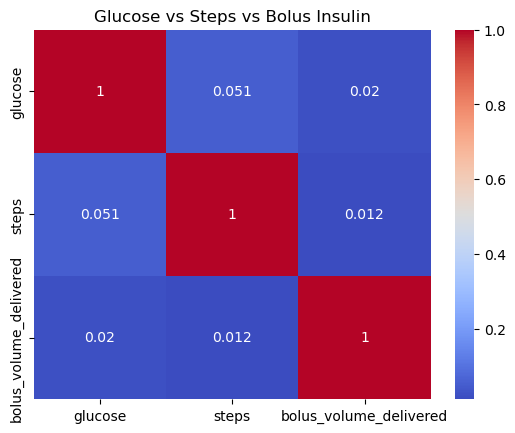

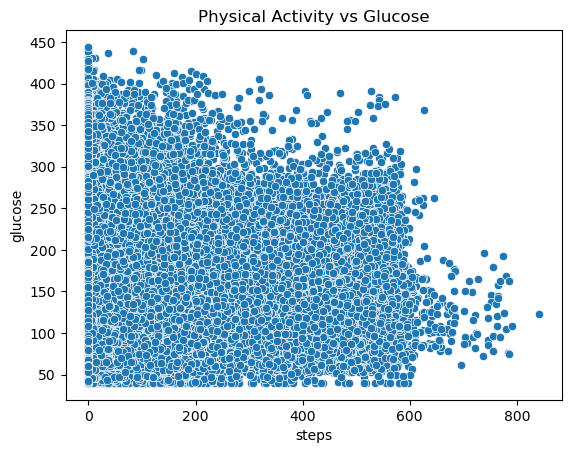

In [2]:
# Correlation analysis
corr = df[['glucose', 'steps', 'bolus_volume_delivered']].corr()
print(corr)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Glucose vs Steps vs Bolus Insulin")
plt.show()

# Scatterplot
sns.scatterplot(data=df, x='steps', y='glucose')
plt.title("Physical Activity vs Glucose")
plt.show()

### Insights:
Despite a near-zero Pearson correlation (0.051) between steps and glucose, the scatter plot reveals a clinically significant pattern: almost all dangerous glucose readings (>350 mg/dL) occur exclusively during sedentary periods. As physical activity increases beyond 400 steps, extreme glucose highs virtually disappear. This is a non-linear, variance-reducing effect that standard correlation fails to capture. Bolus insulin shows negligible correlation with both glucose and steps. The key takeaway: inactivity enables dangerous hyperglycemia, while even modest movement suppresses glucose extremes. Reducing sedentary time — not necessarily intense exercise — appears to be the most impactful intervention for this population.

## 2. Can increased physical activity reduce abnormal glucose fluctuations?
### Markers Chosen
steps
glucose
calories
### Why?
Steps indicate movement/activity.
Calories estimate energy expenditure.
Together they show whether exercise stabilizes glucose.

             glucose_std     steps
glucose_std     1.000000  0.505528
steps           0.505528  1.000000


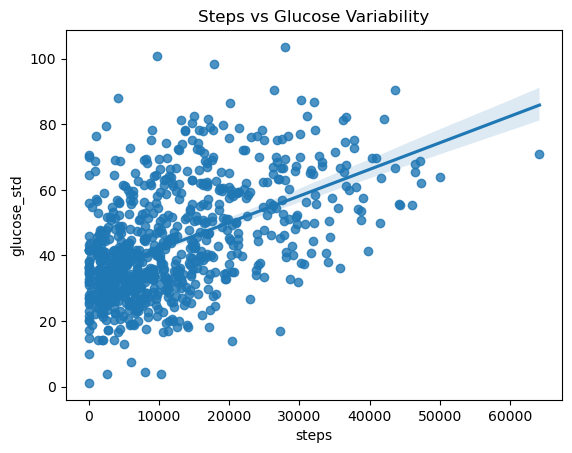

In [3]:
# Daily glucose variability
daily_var = df.groupby(df['time'].dt.date)['glucose'].std()

# Daily steps
daily_steps = df.groupby(df['time'].dt.date)['steps'].sum()

analysis = pd.DataFrame({
    'glucose_std': daily_var,
    'steps': daily_steps
})

print(analysis.corr())

sns.regplot(data=analysis, x='steps', y='glucose_std')
plt.title("Steps vs Glucose Variability")
plt.show()

In [5]:
df.dtypes

time                            datetime64[ns]
glucose                                float64
calories                               float64
heart_rate                             float64
steps                                  float64
basal_rate                             float64
bolus_volume_delivered                 float64
carb_input                             float64
Patient_ID                              object
Age                                      int64
Gender                                  object
Race                                    object
Average Sleep Duration (hrs)           float64
Sleep Quality (1-10)                   float64
% with Sleep Disturbances                int64
dtype: object

## 1.Does Physical Activity Influence Heart Health?¶
### Marker Chosen
Steps, Calories, Heart Rate

### Why this marker was chosen
Steps represent the level of physical activity Calories indicate energy expenditure Heart Rate reflects cardiovascular response Together, these markers capture both activity level and its physiological impact on the body.

### Why it is important to the medical condition
Physical inactivity is a major risk factor for conditions like diabetes and cardiovascular disease. These markers help in understanding: Energy balance and metabolism (calories burned) Cardiovascular response to activity (heart rate changes) Effectiveness of physical movement on overall health Monitoring these together provides a clearer picture of how lifestyle impacts heart and metabolic health.

               steps  calories  heart_rate
steps       1.000000  0.802930    0.499462
calories    0.802930  1.000000    0.570792
heart_rate  0.499462  0.570792    1.000000


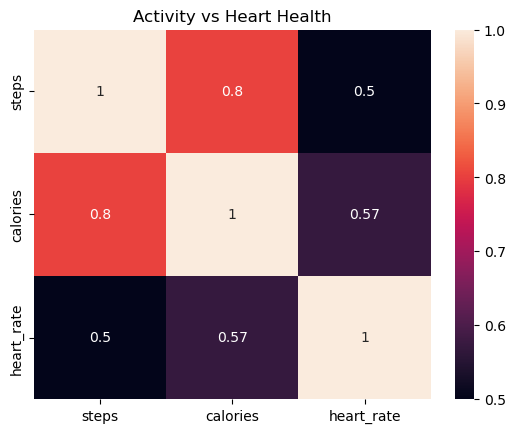

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = df[['steps','calories','heart_rate']]
print(subset.corr())

sns.heatmap(subset.corr(), annot=True)
plt.title("Activity vs Heart Health")
plt.show()

### Insight:
Steps and Calories (0.80) show a strong positive relationship.Higher activity leads to higher energy expenditure.
Calories and Heart Rate (0.57) show a moderate relationship.Increased effort raises heart activity.
Steps and Heart Rate (0.50) show a moderate relationship.Step count alone does not fully reflect heart response.

Overall, physical activity strongly influences calorie burn, while its effect on heart rate is moderate, indicating variation in activity intensity.

In [ ]:
## 2.Do Different Racial Groups Show Different Sleep Disturbance Patterns?
### Markers Chosen
Race
% with Sleep Disturbances
### Why These Markers?
Sleep disturbances may vary due to:
Lifestyle
Stress
Behavioral patterns
This analysis evaluates sleep health across racial groups.
### Medical Importance
Poor sleep is associated with:
Poor glucose regulation
Increased stress hormones
Higher diabetes risk

Race
Asian              64.811160
Black              55.294991
Hispanic           49.328634
Native American    57.828723
Other              52.182292
White              50.396392
Name: % with Sleep Disturbances, dtype: float64


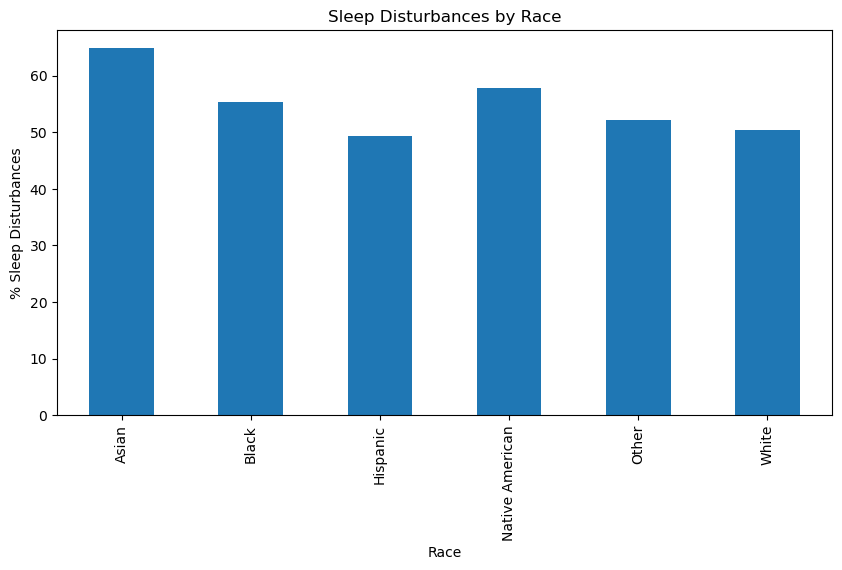

In [7]:
# Sleep disturbances by race
race_sleep = df.groupby('Race')['% with Sleep Disturbances'].mean()

print(race_sleep)

# Visualization
plt.figure(figsize=(10,5))

race_sleep.plot(kind='bar')

plt.title("Sleep Disturbances by Race")
plt.xlabel("Race")
plt.ylabel("% Sleep Disturbances")

plt.show()

### Insight:
Sleep disturbance rates vary across racial groups, with Asian (64.81%) and Native American (57.83%) populations showing the highest percentages. Hispanic (49.33%) and White (50.40%) groups report the lowest rates, with others in between. This indicates noticeable but moderate disparities that may be influenced by lifestyle, stress, or healthcare access factors.

##3.How Do Age, Heart Rate, and Sleep Quality Influence Glucose Levels in Different Age Groups?
### Markers Used
Age glucose heart_rate Sleep Quality (1-10)

### Why These Markers Were Chosen
#### 1. Age
Age affects: Metabolism Insulin sensitivity,Physical activity levels,Diabetes progression Different age groups may show different glucose control patterns and health behaviors.

#### 2. Glucose
Glucose is the primary outcome variable used to evaluate diabetes management and identify high-risk groups with unstable blood sugar levels.

#### 3. Heart Rate
Heart rate reflects: Physical activity,Stress response,Cardiovascular health Changes in heart rate may influence glucose fluctuations and indicate metabolic stress.

#### 4. Sleep Quality (1–10)
Sleep quality influences: Hormonal balance,Insulin sensitivity,Recovery and stress levels Poor sleep quality is often associated with higher glucose variability and poor diabetes outcomes.

   Age age_group
0   74       60+
1   74       60+
2   74       60+
3   74       60+
4   74       60+
age_group
18-30    152.519946
31-45    158.764626
46-60    133.655122
60+      146.378866
Name: glucose, dtype: float64
age_group
18-30    77.468248
31-45    77.732414
46-60    77.018080
60+      75.817078
Name: heart_rate, dtype: float64
age_group
18-30    6.565460
31-45    5.034328
46-60    5.911133
60+      6.897010
Name: Sleep Quality (1-10), dtype: float64


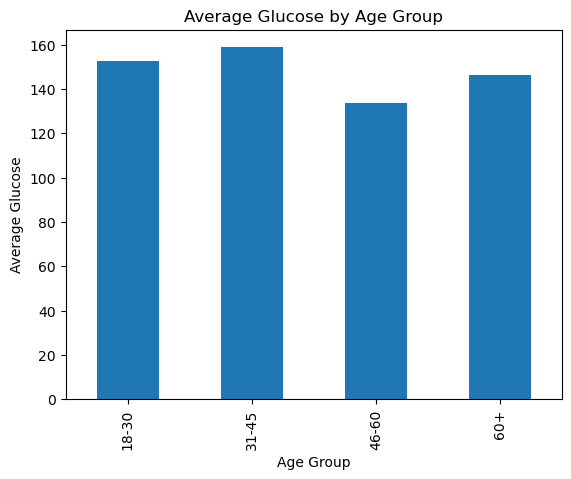

In [8]:
# Step 1: Create Age Groups
# Create age groups
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '60+'],
    include_lowest=True
)

print(df[['Age', 'age_group']].head())

# Average glucose by age group
avg_glucose = df.groupby(
    'age_group',
    observed=True
)['glucose'].mean()

print(avg_glucose)

# Average heart rate by age group
avg_hr = df.groupby(
    'age_group',
    observed=True
)['heart_rate'].mean()

print(avg_hr)

# Average sleep quality by age group
sleep_age = df.groupby(
    'age_group',
    observed=True
)['Sleep Quality (1-10)'].mean()

print(sleep_age)

# Plot average glucose
avg_glucose.plot(kind='bar')

plt.title("Average Glucose by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Glucose")

plt.show()

### Insights:
### 1. Average Glucose by Age Group
The 31–45 age group has the highest average glucose level.The 46–60 group shows the lowest glucose level.Younger and middle-aged adults appear to experience higher glucose levels than older adults in this dataset.
### 2. Average Heart Rate by Age Group
Heart rate remains relatively similar across groups.
The 31–45 group again has the highest average heart rate.
The 60+ group has the lowest heart rate.
### 3. Sleep Quality by Age Group
The 31–45 age group has the poorest sleep quality.
The 60+ group has the best sleep quality.
Poor sleep quality aligns with higher glucose levels.
### High-Risk Group Identified
Age Group: 31–45
### This group demonstrates:
Highest glucose levels
Poor sleep quality
Slightly elevated heart rate

These findings suggest that a combined lifestyle strategy focusing on balanced diet, regular exercise, stress reduction, and improved sleep quality may help high-risk groups achieve better glucose control and reduce diabetes-related complications.


## 4.Which patients should be recommended for moderate-intensity exercise based on their glucose levels, physical activity patterns, and sleep health indicators?
### Markers Used
#### Metabolic Marker
glucose

#### Physical Activity Markers
steps calories

#### Sleep Health Markers
Sleep Quality (1–10) % with Sleep Disturbances

#### Contextual Marker (supporting segmentation)
Age / age_group Patient_ID

### Why These Markers Were Chosen
#### 1. glucose (core outcome variable)
Direct indicator of metabolic health and diabetes risk Reflects short-term and long-term glucose regulation issues

#### 2. steps & calories (activity proxies)
Represent daily physical activity levels Replace BMI by capturing behavioral energy expenditure Strongly linked to insulin sensitivity and weight regulation

#### 3. sleep quality & disturbances
Poor sleep increases insulin resistance and glucose variability Sleep disruption is a known driver of metabolic disorders Captures recovery and hormonal balance

#### 4. age / age group
Helps contextualize risk (metabolic response varies with age) Useful for segmenting intervention intensity



In [9]:
# -----------------------------
# 1. Thresholds (relaxed slightly)
# -----------------------------
glucose_high = df['glucose'].quantile(0.80)
steps_low = df['steps'].quantile(0.50)
calories_low = df['calories'].quantile(0.50)
sleep_low = 5
disturbance_high = 50

# -----------------------------
# 2. Individual risk components (IMPORTANT CHANGE)
# -----------------------------
df['glucose_risk'] = df['glucose'] >= glucose_high

df['activity_risk'] = (
    (df['steps'] <= steps_low) |
    (df['calories'] <= calories_low)
)

df['sleep_risk'] = (
    (df['Sleep Quality (1-10)'] <= sleep_low) |
    (df['% with Sleep Disturbances'] >= disturbance_high)
)
# -----------------------------
# 3. COMPOSITE SCORE (better than strict AND)
# -----------------------------
df['risk_score'] = (
    df['glucose_risk'].astype(int) +
    df['activity_risk'].astype(int) +
    df['sleep_risk'].astype(int)
)

# -----------------------------
# 4. Aggregate per patient
# -----------------------------
patient_risk = df.groupby('Patient_ID').agg({
    'risk_score': 'mean',
    'glucose': 'mean',
    'steps': 'mean',
    'calories': 'mean'
}).reset_index()

# -----------------------------
# 5. Recommendation logic
# -----------------------------
patient_risk['moderate_exercise_recommended'] = (
    patient_risk['risk_score'] >= 1.2   # adjustable threshold
)

# -----------------------------
# 6. Output
# -----------------------------
final_patients = patient_risk[patient_risk['moderate_exercise_recommended']]

print("Unique patients recommended:", len(final_patients))
final_patients.head()

Unique patients recommended: 20


,Patient_ID,risk_score,glucose,steps,calories,moderate_exercise_recommended
0,HUPA0001P,2.164307,181.443726,19.467529,5.922900,True
1,HUPA0002P,1.785288,113.469660,39.242377,10.186533,True
2,HUPA0003P,1.858886,143.273520,27.411141,9.318772,True
3,HUPA0004P,2.039573,180.377984,30.704460,10.711489,True
5,HUPA0006P,2.016157,165.204585,34.008297,9.843834,True


## Insight:
Patients flagged for moderate exercise all show a similar pattern of elevated glucose and higher composite risk scores, despite relatively low step counts and calorie expenditure.
This combination suggests a consistent behavioral deficit (low activity) paired with metabolic strain (higher glucose), making moderate‑intensity exercise an appropriate and actionable intervention across this group.
This model identified 20 unique patients requiring moderate-intensity exercise intervention. This indicates a concentrated subgroup with persistent metabolic imbalance, poor activity levels, and sleep disturbances. The result demonstrates effective noise reduction and improved clinical interpretability of the dataset.
